### Machine Learning Assignement 2
Authors : Muzaffar Izamuddin, Haniy Turana, Clara Wong, Ahmad Mujahid

WIP


# Part A: Exploratory Analysis and Class Distribution

**Dataset description**

- Source file: `ASSG22026.csv`
- Observations: 1500
- Features: 15 numeric features named `feature_1` through `feature_15`
- Target: binary `target` column with imbalanced classes

This dataset appears to be a supervised binary classification problem with all numeric predictors. The target column is the event of interest, and initial exploration should focus on how frequently each class occurs and whether the dataset is strongly skewed toward one label.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# Load the dataset
file_path = 'ASSG22026.csv'
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget value counts:')
print(df['target'].value_counts(dropna=False))

# Show the first few rows
print('\nFirst five rows:')
print(df.head())

Dataset shape: (1500, 16)

Columns: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'target']

Target value counts:
target
0    1420
1      80
Name: count, dtype: int64

First five rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   1.286759  -3.452735  -0.595082   2.852650   5.289887  -0.366363   
1  -0.445937  -4.098332  -0.678555   0.242937   4.107822  -1.645675   
2   1.654022  -1.064226  -1.480801  -0.719527   2.978319   0.482093   
3  -2.432039   3.309322  -0.458722  -1.967034  -4.950714   0.108292   
4  -1.084632   1.105736  -0.208542   0.297446  -1.669344   0.609055   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0   4.533496   0.347942   0.717730   -0.645499    5.186470    0.202211   
1   4.933900  -0.415859   0.107588   -1.912968    3.911879    1.950317   
2  -1.0543

C:\Users\PC 14\AppData\Local\Temp\ipykernel_29476\2105068031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


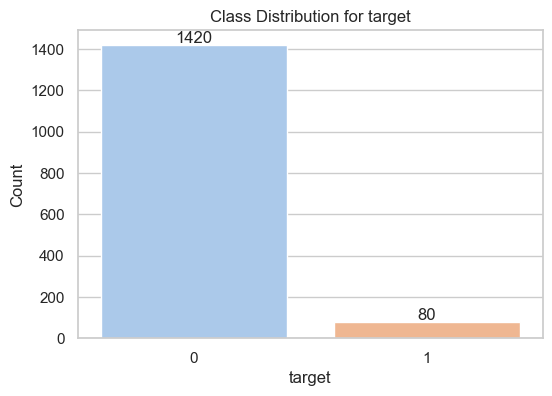

In [2]:
# Visualize the class distribution for the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Class Distribution for target')
plt.xlabel('target')
plt.ylabel('Count')

counts = df['target'].value_counts().sort_index()
for index, value in enumerate(counts):
    plt.text(index, value + 10, str(value), ha='center')

plt.show()

## Implications of Class Imbalance on Predictive Model Performance

- **Biased predictions**: Many classifiers will favor the majority class, especially when trained with default settings. This can lead to models that predict the majority label most of the time and fail to detect the minority event.
- **Misleading accuracy**: A high overall accuracy is possible even if the model never correctly predicts the rare class. For example, if the minority class is only 5%, a model that always predicts the majority class still achieves 95% accuracy.
- **Poor recall for minority class**: Imbalanced data often leads to low recall for the rare class, which is problematic when the rare event is the one we most care about (fraud, disease, failure, etc.).
- **Evaluation metric selection**: Metrics such as precision, recall, F1-score, and AUC are more informative than accuracy for imbalanced classification. They help show how well the model identifies the minority class and balances false positives against false negatives.
- **Need for resampling or weighting**: Handling imbalance explicitly through resampling methods, algorithmic class weights, cost-sensitive learning, or threshold adjustment is usually necessary to build a reliable predictive model for this dataset.

# Part B: Baseline Model

This section trains baseline models on the original imbalanced dataset. No oversampling, undersampling, SMOTE, class weighting, or threshold adjustment is applied here, so these results can be used as the reference point for Part C.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training class distribution:')
print(y_train.value_counts().sort_index())
print('\nTesting class distribution:')
print(y_test.value_counts().sort_index())

Training class distribution:
target
0    1136
1      64
Name: count, dtype: int64

Testing class distribution:
target
0    284
1     16
Name: count, dtype: int64


## Baseline Models

- **Logistic regression** is trained with feature scaling because it is sensitive to feature magnitude.
- **Decision tree** is trained directly on the numeric features because tree splits are scale-invariant.
- Both models use default class treatment, so the original 0/1 imbalance remains unchanged.

In [4]:
baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
}


def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
    }


baseline_results = [
    evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    for name, model in baseline_models.items()
]

baseline_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions']}
    for result in baseline_results
])

baseline_metrics.round(4)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.9500,1.0,0.0625,0.1176,0.7771
1,Decision Tree,0.9367,0.4,0.3750,0.3871,0.6717


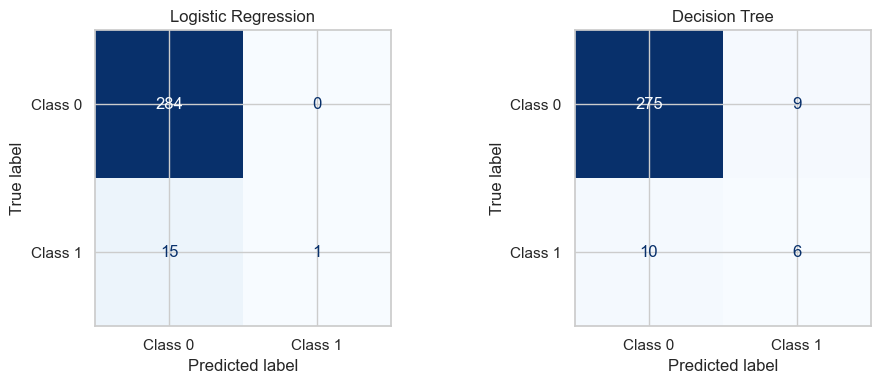

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, baseline_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(result['Model'])

plt.tight_layout()
plt.show()

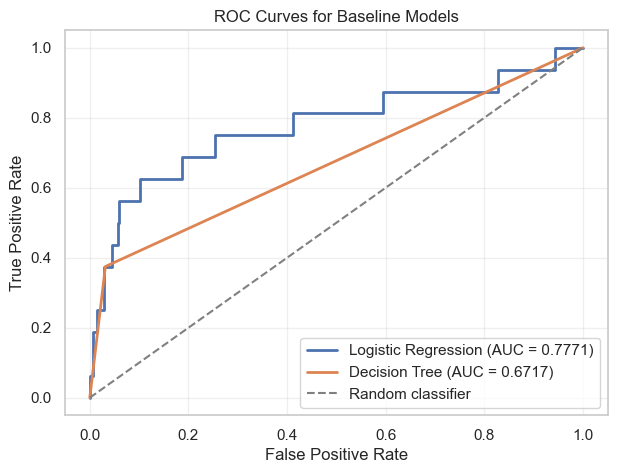

In [6]:
# Plot ROC curves for both baseline models and display AUC values
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 5))

for model_name, model in baseline_models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.title('ROC Curves for Baseline Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Baseline Results Discussion

The baseline results show why accuracy can be misleading for this imbalanced problem. The test set contains 284 majority-class observations and only 16 minority-class observations. Logistic regression achieves about 95% accuracy, but its recall for the minority class is only 0.0625, meaning it correctly detects only 1 out of 16 minority cases. Its high accuracy mainly comes from correctly predicting the majority class.

The decision tree has slightly lower accuracy at about 93.67%, but it identifies 6 out of 16 minority cases, giving a better recall and F1-score than logistic regression. This makes the decision tree the stronger baseline if detecting the minority event is more important than simply maximizing overall accuracy.

For Part C, the decision tree can be treated as the selected baseline model to improve with imbalance-handling methods, while logistic regression remains useful as a comparison point.

# Part C: Addressing Imbalance with SMOTE

## 1.0 Addressing Imbalance with SMOTE

SMOTE, or Synthetic Minority Oversampling Technique, handles class imbalance by generating synthetic minority-class samples from the training data. Instead of simply duplicating existing minority observations, SMOTE creates new points between nearby minority examples. This gives the model more minority-class patterns to learn from while keeping the test set untouched for fair evaluation.

For this experiment, the **Decision Tree** is retrained because it was the stronger baseline model in Part B for detecting the minority class. Logistic Regression is also retrained with SMOTE as an additional comparison, because SMOTE is a data-level method and can be used with any classifier after the training data is balanced.

In [7]:
# Import SMOTE. Install imbalanced-learn automatically if it is missing.
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

In [8]:
# Apply SMOTE only to the training data to avoid data leakage
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_distribution = pd.DataFrame({
    'Original training set': y_train.value_counts().sort_index(),
    'After SMOTE': y_train_smote.value_counts().sort_index(),
})

smote_distribution

,Original training set,After SMOTE
target,,
0,1136,1136
1,64,1136


In [9]:
# Retrain Logistic Regression and Decision Tree using SMOTE-balanced training data
smote_models = {
    'Logistic Regression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Decision Tree': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
}

smote_results = []

for model_name, model in smote_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    smote_results.append({
        'Method': 'SMOTE',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

smote_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in smote_results
])

smote_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,SMOTE,Logistic Regression,0.7533,0.1375,0.6875,0.2292,0.7691
1,SMOTE,Decision Tree,0.9000,0.2812,0.5625,0.3750,0.7408


In [10]:
# Compare baseline results against SMOTE results for both models
baseline_comparison = baseline_metrics.copy()
baseline_comparison.insert(0, 'Method', 'Baseline')

smote_comparison = pd.concat(
    [baseline_comparison, smote_metrics],
    ignore_index=True,
)

smote_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,SMOTE,Logistic Regression,0.7533,0.1375,0.6875,0.2292,0.7691
3,SMOTE,Decision Tree,0.9000,0.2812,0.5625,0.3750,0.7408


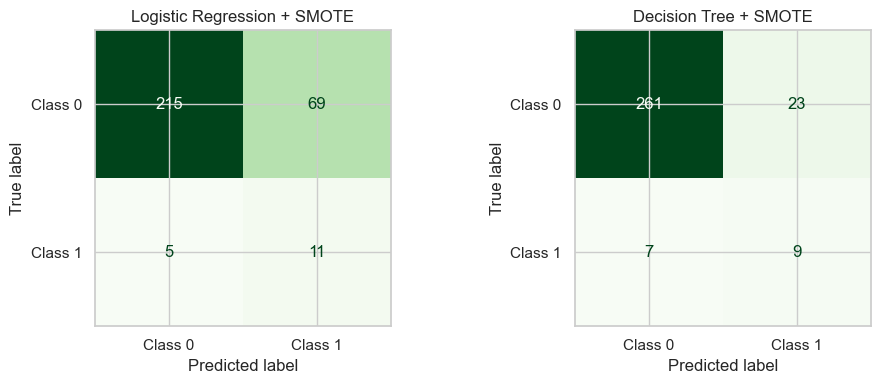

In [11]:
# Confusion matrices for both SMOTE-trained models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, smote_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f"{result['Model']} + SMOTE")

plt.tight_layout()
plt.show()

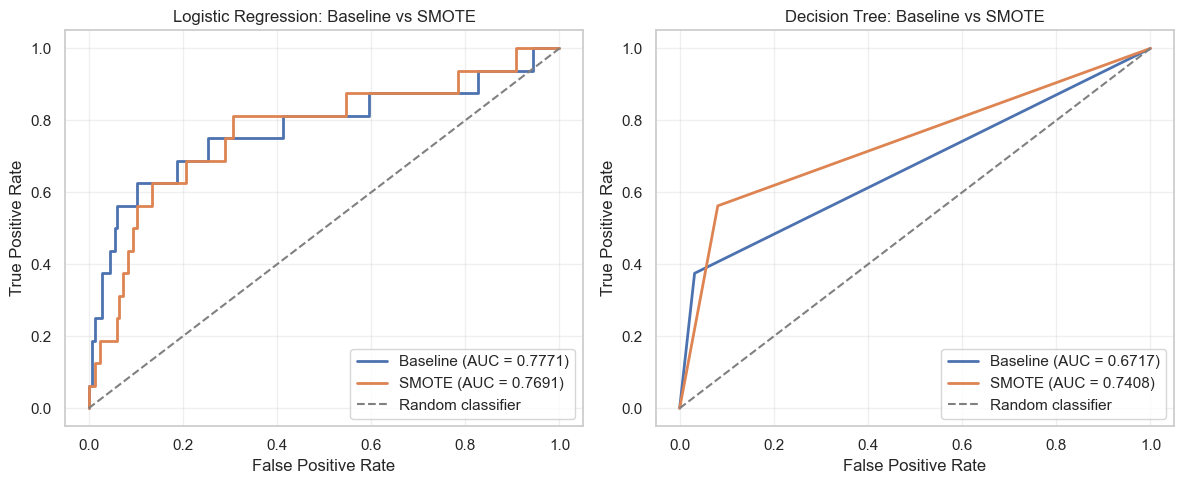

In [12]:
# ROC curve comparison: baseline vs SMOTE for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    smote_model = smote_models[model_name]
    smote_score = smote_model.predict_proba(X_test)[:, 1]
    smote_fpr, smote_tpr, _ = roc_curve(y_test, smote_score)
    smote_auc = roc_auc_score(y_test, smote_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        smote_fpr,
        smote_tpr,
        linewidth=2,
        label=f'SMOTE (AUC = {smote_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs SMOTE')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.1 SMOTE Results Discussion

The comparison table shows that SMOTE improves minority-class recall for both models, but it also increases false positives. Logistic Regression changes the most: recall improves from **0.0625** to **0.6875**, meaning it detects 11 out of 16 minority cases instead of only 1. However, precision drops from **1.0000** to **0.1375** and accuracy falls from **0.9500** to **0.7533**, because the model now predicts many more minority cases.

For the Decision Tree, SMOTE improves recall from **0.3750** to **0.5625** and AUC from **0.6717** to **0.7408**. Accuracy decreases from **0.9367** to **0.9000**, and precision decreases from **0.4000** to **0.2813**. This is a smaller trade-off than Logistic Regression while still improving detection of the minority class.

Overall, SMOTE is useful when the deployment goal is to catch more minority events, even at the cost of more false alarms. Among the two SMOTE models, Logistic Regression gives the highest recall, while the SMOTE Decision Tree gives a more balanced trade-off between recall, precision, accuracy, and AUC.

## 2.0 Cost-Sensitive Learning

### Method Explanation

Cost-sensitive learning handles class imbalance by assigning a higher penalty to mistakes on the minority class. Instead of changing the data distribution like SMOTE, it changes how the model treats errors during training. In scikit-learn, this can be done with `class_weight='balanced'`, which automatically gives larger weight to the minority class and smaller weight to the majority class based on their frequencies.

In this section, both Logistic Regression and Decision Tree are retrained using class-weight adjustment. This follows the same comparison flow as Section 1.0: retrain the models, report all metrics again, compare against the baseline models, visualize confusion matrices, plot ROC curves, and discuss the trade-offs.

In [13]:
# Retrain Logistic Regression and Decision Tree using cost-sensitive class weights
cost_sensitive_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight='balanced',
        )),
    ]),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced',
    ),
}

cost_sensitive_results = []

for model_name, model in cost_sensitive_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    cost_sensitive_results.append({
        'Method': 'Cost-sensitive',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

cost_sensitive_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in cost_sensitive_results
])

cost_sensitive_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Cost-sensitive,Logistic Regression,0.7600,0.1316,0.6250,0.2174,0.7760
1,Cost-sensitive,Decision Tree,0.9233,0.2941,0.3125,0.3030,0.6351


In [14]:
# Compare baseline results against cost-sensitive learning results for both models
cost_sensitive_comparison = pd.concat(
    [baseline_comparison, cost_sensitive_metrics],
    ignore_index=True,
)

cost_sensitive_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,Cost-sensitive,Logistic Regression,0.7600,0.1316,0.6250,0.2174,0.7760
3,Cost-sensitive,Decision Tree,0.9233,0.2941,0.3125,0.3030,0.6351


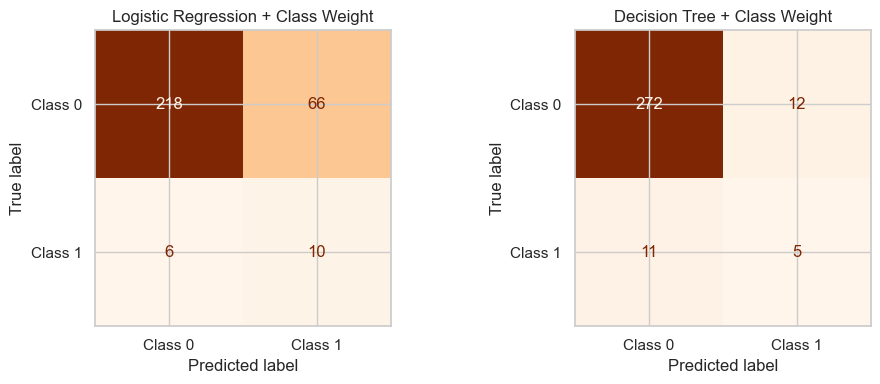

In [15]:
# Confusion matrices for both cost-sensitive models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, cost_sensitive_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f"{result['Model']} + Class Weight")

plt.tight_layout()
plt.show()

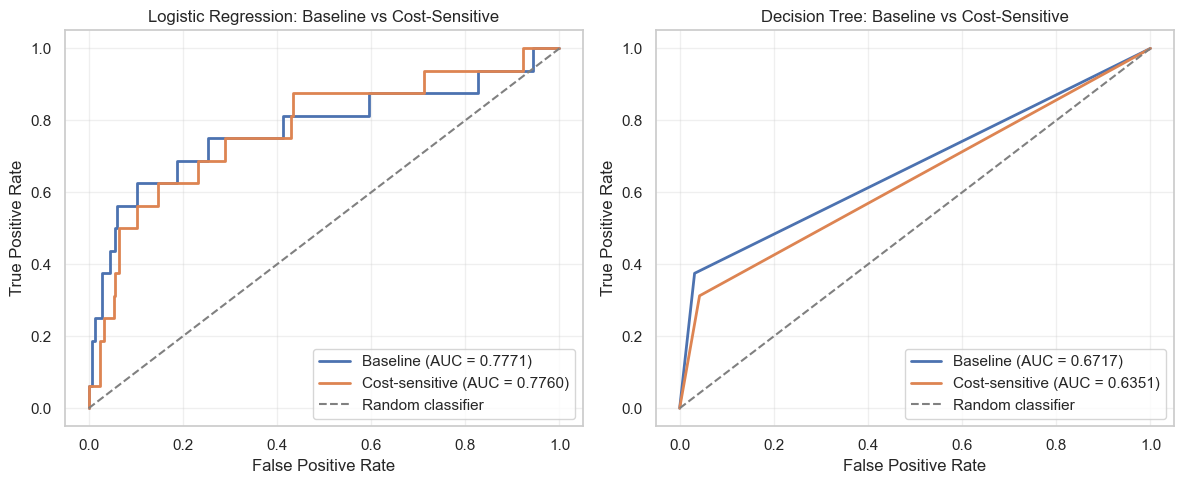

In [16]:
# ROC curve comparison: baseline vs cost-sensitive learning for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    cost_model = cost_sensitive_models[model_name]
    cost_score = cost_model.predict_proba(X_test)[:, 1]
    cost_fpr, cost_tpr, _ = roc_curve(y_test, cost_score)
    cost_auc = roc_auc_score(y_test, cost_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        cost_fpr,
        cost_tpr,
        linewidth=2,
        label=f'Cost-sensitive (AUC = {cost_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs Cost-Sensitive')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.1 Cost-Sensitive Learning Results Discussion

Cost-sensitive learning improves minority-class recall for Logistic Regression. The baseline Logistic Regression detected only 1 out of 16 minority cases, with recall of **0.0625**. With `class_weight='balanced'`, it detects 10 out of 16 minority cases, increasing recall to **0.6250**. However, precision drops from **1.0000** to **0.1316**, and accuracy drops from **0.9500** to **0.7600**, because the model now predicts many more minority cases and produces more false positives.

For the Decision Tree, class weighting does not improve the result on this split. Recall decreases from **0.3750** to **0.3125**, F1-score decreases from **0.3871** to **0.3030**, and AUC decreases from **0.6717** to **0.6351**. This suggests that simply weighting the tree's impurity criterion is not enough for this dataset and may make the tree split less effectively.

Overall, cost-sensitive learning is most useful here for Logistic Regression when the priority is reducing false negatives. Compared with SMOTE, weighted Logistic Regression gives slightly lower recall than SMOTE Logistic Regression but similar AUC. The weighted Decision Tree is weaker than the SMOTE Decision Tree for this dataset.

## 3.0 Balanced Bagging

### Method Explanation

Balanced bagging is an ensemble method designed for imbalanced classification. It trains multiple models on different bootstrap samples, but each sample is balanced by undersampling the majority class. The predictions from all models are then combined, usually by voting or averaging probabilities.

This method can reduce the majority-class bias while also benefiting from ensemble stability. In this section, Balanced Bagging is applied to both Logistic Regression and Decision Tree so the results can be compared against the original baseline models using the same metrics and plots as the previous Part C methods.

In [33]:
# Import BalancedBaggingClassifier. Install imbalanced-learn automatically if it is missing.
try:
    from imblearn.ensemble import BalancedBaggingClassifier
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.ensemble import BalancedBaggingClassifier

In [34]:
# Retrain Logistic Regression and Decision Tree using Balanced Bagging
balanced_bagging_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', BalancedBaggingClassifier(
            estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            n_estimators=50,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ]),
    'Decision Tree': BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

balanced_bagging_results = []

for model_name, model in balanced_bagging_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    balanced_bagging_results.append({
        'Method': 'Balanced Bagging',
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_score),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Scores': y_score,
    })

balanced_bagging_metrics = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['Confusion Matrix', 'Predictions', 'Scores']}
    for result in balanced_bagging_results
])

balanced_bagging_metrics.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Balanced Bagging,Logistic Regression,0.7633,0.1519,0.750,0.2526,0.7810
1,Balanced Bagging,Decision Tree,0.8933,0.2778,0.625,0.3846,0.8539


In [35]:
# Compare baseline results against Balanced Bagging results for both models
balanced_bagging_comparison = pd.concat(
    [baseline_comparison, balanced_bagging_metrics],
    ignore_index=True,
)

balanced_bagging_comparison.round(4)

,Method,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline,Logistic Regression,0.9500,1.0000,0.0625,0.1176,0.7771
1,Baseline,Decision Tree,0.9367,0.4000,0.3750,0.3871,0.6717
2,Balanced Bagging,Logistic Regression,0.7633,0.1519,0.7500,0.2526,0.7810
3,Balanced Bagging,Decision Tree,0.8933,0.2778,0.6250,0.3846,0.8539


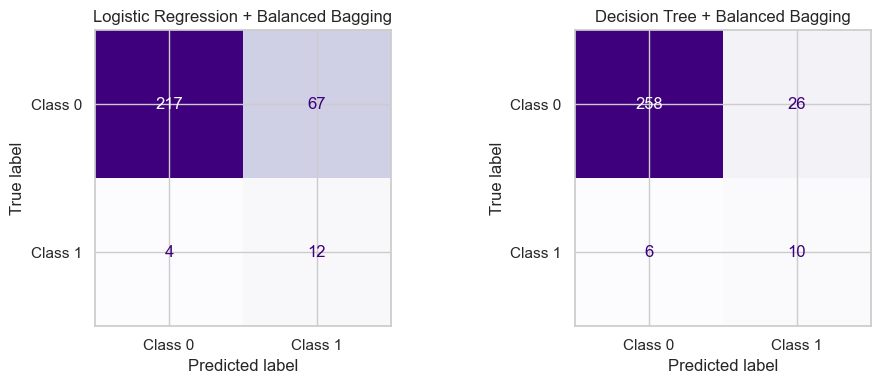

In [36]:
# Confusion matrices for both Balanced Bagging models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, balanced_bagging_results):
    ConfusionMatrixDisplay(
        confusion_matrix=result['Confusion Matrix'],
        display_labels=['Class 0', 'Class 1'],
    ).plot(ax=ax, cmap='Purples', colorbar=False)
    ax.set_title(f"{result['Model']} + Balanced Bagging")

plt.tight_layout()
plt.show()

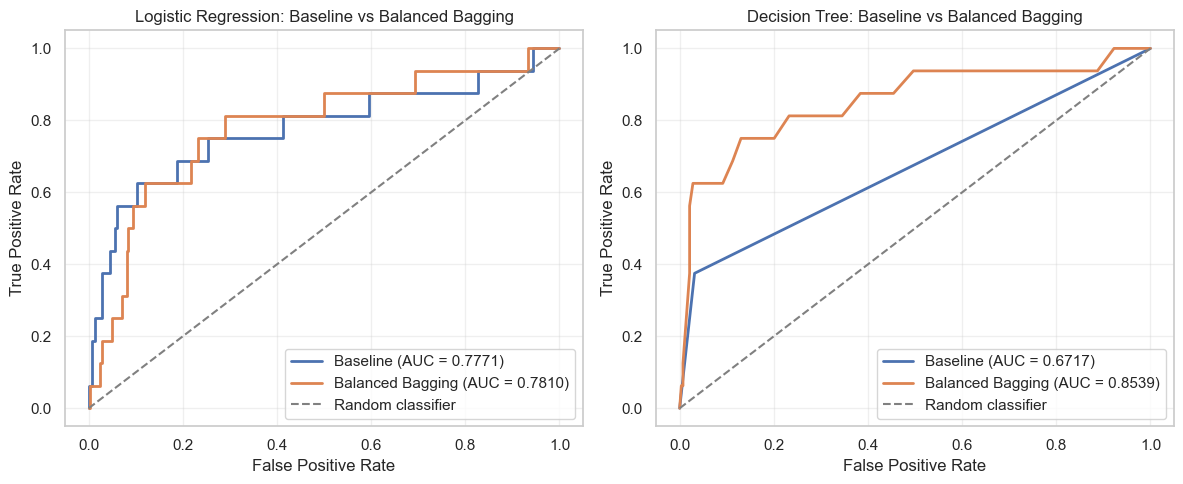

In [37]:
# ROC curve comparison: baseline vs Balanced Bagging for each model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

roc_pairs = [
    ('Logistic Regression', axes[0]),
    ('Decision Tree', axes[1]),
]

for model_name, ax in roc_pairs:
    baseline_model = baseline_models[model_name]
    baseline_score = baseline_model.predict_proba(X_test)[:, 1]
    baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_score)
    baseline_auc = roc_auc_score(y_test, baseline_score)

    bagging_model = balanced_bagging_models[model_name]
    bagging_score = bagging_model.predict_proba(X_test)[:, 1]
    bagging_fpr, bagging_tpr, _ = roc_curve(y_test, bagging_score)
    bagging_auc = roc_auc_score(y_test, bagging_score)

    ax.plot(
        baseline_fpr,
        baseline_tpr,
        linewidth=2,
        label=f'Baseline (AUC = {baseline_auc:.4f})',
    )
    ax.plot(
        bagging_fpr,
        bagging_tpr,
        linewidth=2,
        label=f'Balanced Bagging (AUC = {bagging_auc:.4f})',
    )
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
    ax.set_title(f'{model_name}: Baseline vs Balanced Bagging')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.1 Balanced Bagging Results Discussion

Balanced Bagging improves minority-class recall for both models. For Logistic Regression, recall increases from **0.0625** to **0.7500**, meaning the model detects 12 out of 16 minority cases instead of only 1. Precision decreases from **1.0000** to **0.1519**, and accuracy decreases from **0.9500** to **0.7633**, because the model predicts more minority cases and therefore creates more false positives.

For the Decision Tree, Balanced Bagging performs especially well compared with the original baseline. Recall increases from **0.3750** to **0.6250**, F1-score is slightly higher at **0.3846**, and AUC improves strongly from **0.6717** to **0.8539**. Accuracy decreases from **0.9367** to **0.8933**, but this is expected because the model is less biased toward the majority class.

Overall, Balanced Bagging is one of the stronger imbalance-handling methods tested so far. It gives the Decision Tree a much better AUC and recall than the baseline while keeping accuracy reasonably high. If the deployment goal is to improve minority detection without relying on synthetic samples, Balanced Bagging is a strong candidate.